# `py4conjoint.choice` — デモ（選択型コンジョイント分析）

このノートブックは `py4conjoint.choice` の基本的な **関数・属性・メソッド** を、
**スマートフォン**（価格・OS・カメラ）を題材にひととおり動かして学ぶための教材です。
回答データは実際の調査ではなく、仮定した選好から作った **合成データ**（教材用）です。

| 部 | 内容 |
|:---:|------|
| **第1部** | 基本フロー（価格2水準）：設計 → アンケート → 読み込み → 符号化 → 推定 → 解釈・可視化 |
| **第2部** | 価格3水準と区間別 WTP：価格を 6/8/10万円にして、価格帯ごとの感応度の違いを捉える |
| 補足 | 合成データの作り方／rating 版（評点型）との違い |

ワークフローは rating 版と対称的です：

```
設計                → アンケート → 読み込み       → 符号化  → 推定  → 解釈
design_choice_sets    Forms       forms_to_data    encode    fit     summary / importance / wtp / market_share
```

# 第1部：基本フロー（価格2水準のスマートフォン）

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import py4conjoint.choice as pcc

print(f"py4conjoint version: {pcc.__version__}")

py4conjoint version: 0.4.0a1


## 1. 選択型コンジョイント分析（CBC）とは

評点型（rating 版）では、回答者に製品案（プロファイル）を **1つずつ** 見せて
「10点満点で何点？」と評価してもらいました。

選択型（CBC：Choice-Based Conjoint）では、回答者に **複数の製品案を同時に**
見せて「この中ならどれを買う？」と **1つ選んでもらいます**。

* 同時に見せる製品案のまとまりを **選択セット**（＝アンケートの1設問）と呼びます。
* お店の棚から1つ選ぶのと同じ行動なので、**実際の購買行動に近い** データが取れます。
* 分析には **条件付きロジット（conditional logit）** を使います。
  「各製品が選ばれる確率」を、属性の魅力度（効用）から説明するモデルです。

ここでは、次の3属性のスマートフォンを題材にします。

| 属性 | 水準 |
|------|------|
| 価格（price） | 6万円 / 10万円（第1部）|
| OS（os） | Apple / Android |
| カメラ（camera） | 標準 / 高性能 |

## 2. `pcc.design_choice_sets()` — 選択セットの設計

CBC 用の選択セット（設問）を生成する関数です。全属性水準の組み合わせ（完全交差）から、
各設問にランダムに代替案を割り当てます。**同じ設問の中に同じ製品案が重複して入ることは
ありません。**

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `attributes` | dict | — | `{"属性名": [水準1, 水準2, ...]}` の辞書 |
| `n_sets` | int | — | 設問数（選択セット数） |
| `n_alts` | int | — | 1設問あたりの代替案の数 |
| `n_versions` | int | `1` | アンケートのバージョン数 |
| `seed` | int | `None` | 乱数シード（再現性のため） |

**返り値**: long 形式 DataFrame（列：`version`, `choice_set_id`, `alt_id` + 属性列）。
1 行 = 1つの設問の中の1つの代替案。

In [2]:
design = pcc.design_choice_sets(
    {"price": [6, 10], "os": ["apple", "android"], "camera": ["標準", "高性能"]},
    n_sets=6,    # 設問数（1人が6問に答える）
    n_alts=3,    # 1設問あたり3つの代替案（製品A・製品B・製品C）から選ぶ
    seed=1096,
)

# 作成した設計はすぐファイルに保存する（分析時は作り直さず、これを読み込む）
design.to_csv("design_smartphone_cbc.csv", index=False)
print("design の署名:", pcc.design_signature(design))
design.head(6)  # 設問1・設問2に提示する代替案

design の署名: 9ef2946f7a86


,version,choice_set_id,alt_id,price,os,camera
0,1,1,1,10,android,標準
1,1,1,2,6,android,高性能
2,1,1,3,10,apple,高性能
3,1,2,1,6,apple,高性能
4,1,2,2,6,android,標準
5,1,2,3,10,android,高性能


> ⚠️ **最も危険な落とし穴：design のずれ**
>
> アンケート作成に使った design と、あとで `forms_to_data()` に渡す design は
> **完全に同一** でなければなりません。属性名・水準・**水準の順序**・`seed`・
> `n_sets`・`n_alts` が1つでも違うと、**同じ `seed` でも別の設計**になります。
> 例えば `{"price": [6, 10]}` と `{"price": [10, 6]}` は seed が同じでも
> 各選択セットの中身が変わります。design がずれると、回答と代替案の対応が
> **エラーが出ないまま食い違い、結果が静かに誤ります**（本来 正 の係数が
> 負 に出るなど）。
>
> **対策**：design は作成後すぐ `design.to_csv(...)` で保存し、分析時は
> `design_choice_sets()` を呼び直さず `pd.read_csv(...)` で**同じファイルを
> 読み込んで**使います（上のセルで保存済み）。2つの design が同一かは
> `pcc.design_signature(design)` の署名で確認できます。

## 3. `pcc.check_design()` — 設計の診断

アンケートを実施する **前** に、作った設計の品質をチェックする関数です。
`summary()`（和文サマリー）と `warnings()`（DataFrame）を持つ
`ChoiceDesignCheckResult` を返します。

| 項目 | 内容 | 良い状態 |
|------|------|---------|
| 水準バランス | 各水準が均等に出現しているか（CV） | CV が小さい（◎） |
| 独立性（χ²） | 2属性の組み合わせが偏っていないか | χ²/自由度 が小さい（◎） |
| セット内オーバーラップ | 設問内の全代替案が同じ水準になる設問の割合 | 率が小さい（◎） |

`seed=1096` はお手本としてきれいな設計になるよう選んであります（警告ゼロ）。

In [3]:
check = pcc.check_design(design)
print(check.summary())

選択セット設計チェック

【水準バランス】（CV が小さいほど均等）
  属性  水準数  最大出現  最小出現   CV  評価
 price       2         9         9  0.0     ◎
    os       2         9         9  0.0     ◎
camera       2         9         9  0.0     ◎

【独立性（χ²統計量）】（自由度に対して小さいほど独立）
属性1   属性2      χ²  自由度  χ²/自由度  評価
price      os  0.2222       1     0.2222     ○
price  camera  0.2222       1     0.2222     ○
   os  camera  0.2222       1     0.2222     ○

【セット内オーバーラップ】（全代替案が同じ水準になる設問の割合。小さいほど良い）
  属性  オーバーラップ率  評価
 price               0.0     ◎
    os               0.0     ◎
camera               0.0     ◎

警告はありません。


## 4. `pcc.suggest_n_respondents()` — 必要回答者数の目安

CBC で何人にアンケートすべきかを **Johnson-Orme の経験則** で計算します。

$$n \;\geq\; \frac{500 \times c}{t \times a}$$

* $c$ … 最大水準数（いちばん水準が多い属性の水準数）
* $t$ … 設問数（1人が答える選択セット数）
* $a$ … 1設問あたりの代替案数

「各水準が少なくとも500回は提示される」ことを目安とするルールです。

In [4]:
pcc.suggest_n_respondents(
    {"price": [6, 10], "os": ["apple", "android"], "camera": ["標準", "高性能"]},
    n_sets=6,
    n_alts=3,
)

Johnson-Orme の経験則: n ≥ 500 × c / (t × a)
  最大水準数 c = 2, 設問数 t = 6, 代替案数 a = 3
  → 必要回答者数の目安: 56 人以上
  （サブグループ別に分析する場合はグループごとにこの人数が必要です）


,水準数,必要回答者数（目安）
属性,,
price,2,56
os,2,56
camera,2,56


> このあと使う合成データは **30名** です。上の目安を下回りますが、
> 教材として一連の流れを動かすには十分です（実際の調査では目安以上を集めましょう）。

## 5. `pcc.forms_to_data()` — アンケートファイルの読み込み

Microsoft Forms（`.xlsx`）/ Google Forms（`.csv`）の回答ファイルを、
条件付きロジット推定用の **long 形式 DataFrame** に変換する関数です。

**前提とするアンケート形式**

* **1設問 = 1選択セット**。設問の回答選択肢が代替案（「製品A」「製品B」「製品C」）。
* 回答値から代替案を特定するために、設計（`design`）と
  `choice_labels`（回答文字列に含まれるラベル）を渡します。

> **推奨ワークフロー**：design は **作り直さず**、セクション2で保存した CSV を
> `pd.read_csv(...)` で読み込んで渡します。これで「作成時と分析時の design が同一」が
> 保証され、署名（`design_signature`）も一致します。

> **Google Forms の CSV について**：Google Forms の回答 CSV は **BOMなし UTF-8** の
> ことが多く、Excel でそのまま開くと文字化けします。しかしファイル自体は正常で、
> `forms="google"` で正しく読み込めます。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `responses_file` | str | — | アンケートファイルのパス（.xlsx / .csv） |
| `design` | DataFrame | — | `design_choice_sets()` の出力（または設計表） |
| `choice_labels` | list | — | 代替案を識別するラベル（`alt_id` の順） |
| `forms` | str | `"microsoft"` | `"microsoft"` または `"google"` |
| `respondent_cols` | dict | `None` | 回答者属性として残したい列の対応辞書 |

**返り値**: long 形式 DataFrame（列：`respondent_id`, `choice_set_id`, `alt`,
`choice`(0/1) + 属性列。rating 版と同じく回答者を先頭にした列順）。

In [5]:
# 分析時は design を作り直さず、保存しておいた設計ファイルを読み込む
design = pd.read_csv("design_smartphone_cbc.csv")     # セクション2で保存した設計
print("読み込んだ design の署名:", pcc.design_signature(design))

# Google Forms の回答 CSV を long 形式に変換する
df = pcc.forms_to_data(
    responses_file="responses_smartphone_google_30.csv",
    design=design,                            # 作成時と同じ設計（署名で確認できる）
    choice_labels=["製品A", "製品B", "製品C"],  # 「製品A」→ alt 1, 「製品B」→ alt 2, ...
    forms="google",
    respondent_cols={                         # 回答者属性として残す列
        "【回答者属性１】あなたの性別を教えてください。": "gender",
        "【回答者属性２】現在使っているスマートフォンのOSはどちらですか？": "used_os",
    },
)
df.head(6)

読み込んだ design の署名: 9ef2946f7a86


,respondent_id,choice_set_id,alt,choice,gender,used_os,price,os,camera
0,1,1,1,0,男性,Android,10,android,標準
1,1,1,2,1,男性,Android,6,android,高性能
2,1,1,3,0,男性,Android,10,apple,高性能
3,1,2,1,1,男性,Android,6,apple,高性能
4,1,2,2,0,男性,Android,6,android,標準
5,1,2,3,0,男性,Android,10,android,高性能


出力は **long 形式**（1行 = 1つの選択セット内の1つの代替案）で、列順は
`respondent_id, choice_set_id, alt, choice, …` と **回答者IDが先頭** です。

- **`respondent_id`** … 「誰が」答えたか（1人 = 1回答者）。
- **`choice_set_id`** … 「どの設問（購買機会）」か。1人が複数の `choice_set_id` を持ちます。
- **`alt`** … 設問内の代替案（製品A/B/C）。各設問でちょうど1つだけ `choice=1`。

同じ回答者の繰り返し回答は独立ではないため、`fit()` は `respondent_id` を使って
**クラスタロバスト標準誤差** を自動で適用します（列名が既定どおりなら指定不要）。

## 6. `pcc.encode()` — ダミーコーディング（0/1）

カテゴリ属性を **0/1 のダミーコーディング** に変換する関数です。

> **rating 版との違い**：rating 版の `encode()` は ±1 の **効果コーディング** でしたが、
> choice 版は 0/1 の **ダミーコーディング** です。条件付きロジットでは「基準水準と比べて
> どれだけ選ばれやすいか」という解釈が直感的なためです。

K 水準の属性 → 基準水準 **以外** の水準ごとに `{属性名}_{水準名}` が K-1 列追加されます。
**価格（`price`）は数値変数なのでダミー化せず**、そのまま説明変数に入れます
（`reference_levels` に `price` を入れない）。

In [6]:
df_coded = pcc.encode(df, reference_levels={"os": "android", "camera": "標準"})
df_coded.head(6)  # os_apple / camera_高性能 が追加される（price はそのまま）

,respondent_id,choice_set_id,alt,choice,gender,used_os,price,os,camera,os_apple,camera_高性能
0,1,1,1,0,男性,Android,10,android,標準,0,0
1,1,1,2,1,男性,Android,6,android,高性能,0,1
2,1,1,3,0,男性,Android,10,apple,高性能,1,1
3,1,2,1,1,男性,Android,6,apple,高性能,1,1
4,1,2,2,0,男性,Android,6,android,標準,0,0
5,1,2,3,0,男性,Android,10,android,高性能,0,1


## 7. `pcc.fit()` — 条件付きロジットの推定

符号化済み DataFrame に **条件付きロジット** を適用し、`ChoiceConjointResult` を返します。

$$P(j) = \frac{\exp(V_j)}{\sum_k \exp(V_k)}, \qquad V_j = \beta_1 x_{j1} + \beta_2 x_{j2} + \cdots$$

$V_j$ は代替案 $j$ の **効用**、係数 $\beta$ は最尤法（scipy.optimize）で推定されます。

> **列名引数は省略できます**。`forms_to_data()` の出力は列名が既定どおり
> （`choice`, `choice_set_id`, `respondent_id`）なので、`fit()` は回答者IDを自動で認識し、
> **クラスタロバスト標準誤差** が効きます。価格列だけ `price_col="price"` で伝えます。

In [7]:
result = pcc.fit(df_coded, price_col="price")
result  # summary() が表示される

============================================================
選択型コンジョイント分析の結果（和文サマリー）
============================================================
観測数（行数）                       : 540
選択セット数（回答者数 × 設問数/人） : 180（30 × 6/人）
説明変数の数                         : 3
対数尤度                             : -150.5307
擬似決定係数 R²（McFadden）          : 0.2388
標準誤差                             : クラスタロバスト（respondent_id）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  price                        -0.3127     0.0000  ***
  os_apple                      0.9428     0.0000  ***
  camera_高性能                 0.5966     0.0034  **

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1
============================================================

係数の読み方（ダミーコーディング）：

* `price` の係数が **負** → 価格が高いほど選ばれにくい（妥当）。
* `os_apple` の係数が **正** → Apple は基準の Android より選ばれやすい。
* `camera_高性能` の係数が **正** → 高性能カメラは基準の標準より選ばれやすい。

**すべて直感どおりの符号** になっています。これは設計とデータの対応がずれていない
ことの目視チェックも兼ねています（もし価格係数が正に出たら、design のずれを疑います）。
また「選択セット数」に **30名 × 6問/人 = 180** の内訳が表示されます。

## 8. 解釈：`importance` / `wtp` / `market_share` / `warnings`

推定結果から、実務で使う4つの指標を取り出します。

| メソッド | 内容 |
|---|---|
| `importance()` | 属性の重要度（効用範囲の比率、合計100%） |
| `wtp()` | 限界支払意思額（属性を金額に換算） |
| `market_share()` | 製品案の市場シェア予測 |
| `warnings()` | 落とし穴の自動チェック |

In [8]:
# 重要度（合計 100%）
result.importance()

,効用範囲,重要度
属性,,
price,1.250902,44.831055
os,0.942786,33.788487
camera,0.596570,21.380458


**WTP（限界支払意思額）**：価格係数で各属性の係数を割り、金額に換算します。

$$\text{MWTP} = -\frac{\beta_{attr}}{\beta_{price}}$$

「基準水準からその水準に変えるために追加で支払ってもよい金額」です。単位は price 列と
同じ **万円** です。

In [9]:
result.wtp()  # 例：Apple であることに +約3万円、高性能カメラに +約1.9万円

,係数,限界支払意思額
属性（符号化列名）,,
os_apple,0.942786,3.014739
camera_高性能,0.596570,1.907647


**市場シェア予測**：複数の製品案について、ロジット式
$\text{share}_i = \exp(u_i) / \sum_j \exp(u_j)$ でシェアを予測します。
`products` の各行は `fit()` の説明変数と同じ列（ダミー列は 0/1、価格は実際の値）を持たせます。

In [10]:
products = pd.DataFrame(
    {                      # 製品X   製品Y   製品Z
        "price":         [  6.0,   10.0,    8.0],
        "os_apple":      [    0,      1,      1],   # 製品Y・Z = Apple
        "camera_高性能": [    0,      1,      0],   # 製品Y = 高性能カメラ
    },
    index=["製品X（Android・6万・標準）",
           "製品Y（Apple・10万・高性能）",
           "製品Z（Apple・8万・標準）"],
)
share = result.market_share(products)
print(share)
print(f"  合計: {share.sum():.4f}")

製品X（Android・6万・標準）    0.269700
製品Y（Apple・10万・高性能）    0.359877
製品Z（Apple・8万・標準）      0.370423
Name: market_share, dtype: float64
  合計: 1.0000


**落とし穴チェック**：推定で自動検出された診断警告の一覧です。
今回はきれいな設計・十分な符号なので、警告は出ません（空の表）。

In [11]:
result.wtp()          # 価格関連の警告も生成させるため先に呼ぶ
result.warnings()

,severity,category,message,recommendation


## 9. 可視化

3つの可視化はいずれも **`result.plot_*()`**（メソッド）と **`pcc.plot_*()`**
（モジュール関数）の2通りで呼べます。すべて `matplotlib.axes.Axes` を返します。

| 関数/メソッド | 説明 |
|---|---|
| `plot_importance()` | 重要度の水平棒グラフ |
| `plot_partworth()` | 各水準の部分効用グラフ（基準水準＝0 も明示） |
| `plot_wtp()` | WTP の水平棒グラフ（`price_unit` で単位を表示） |

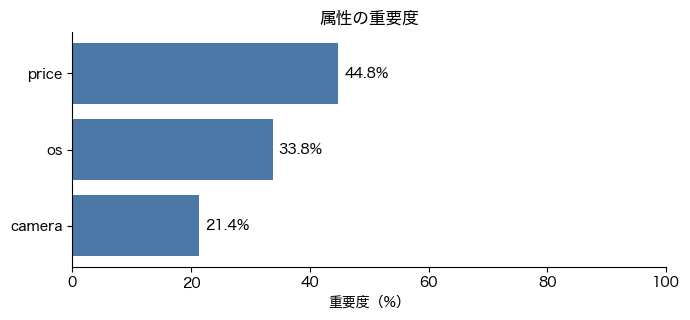

In [12]:
# 重要度
ax = result.plot_importance()

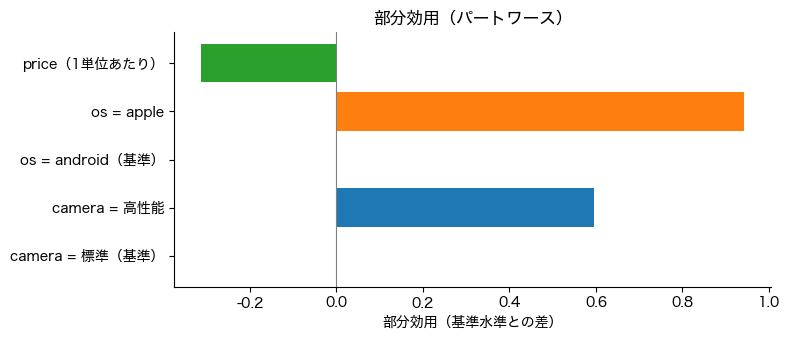

In [13]:
# 部分効用（基準水準 Android / 標準 の棒が 0 の位置にあることを確認）
ax = result.plot_partworth()

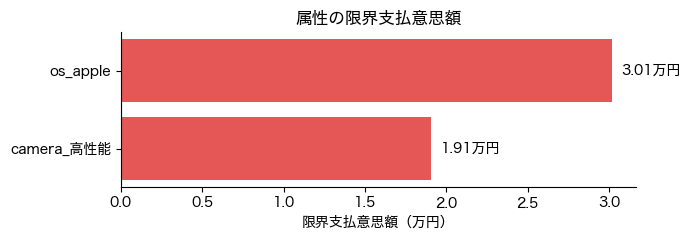

In [14]:
# WTP（単位：万円）
ax = result.plot_wtp(price_unit="万円")

# 第2部：価格3水準と区間別 WTP

第1部では価格を **6/10万円の2水準** にしました。価格を **6/8/10万円の3水準** にすると、
価格に対する敏感さ（WTP）が **価格帯ごとに変わる** ようすを捉えられます。

例えば「8万円→10万円の値上げ」は「6万円→8万円の値上げ」より敬遠されやすい、
といった **非線形な価格選好** です。これを **区間別 WTP** で読み取ります。

## 10. 3水準の設計を作る

価格を `[6, 8, 10]` にして、同じ手順で設計を作り、保存し、診断します。

In [15]:
design3 = pcc.design_choice_sets(
    {"price": [6, 8, 10], "os": ["apple", "android"], "camera": ["標準", "高性能"]},
    n_sets=6,
    n_alts=3,
    seed=643,
)
design3.to_csv("design_smartphone_3price.csv", index=False)
print("design3 の署名:", pcc.design_signature(design3))
print(pcc.check_design(design3).summary())

design3 の署名: 939ee8113576
選択セット設計チェック

【水準バランス】（CV が小さいほど均等）
  属性  水準数  最大出現  最小出現   CV  評価
 price       3         6         6  0.0     ◎
    os       2         9         9  0.0     ◎
camera       2         9         9  0.0     ◎

【独立性（χ²統計量）】（自由度に対して小さいほど独立）
属性1   属性2      χ²  自由度  χ²/自由度  評価
price      os     0.0       2        0.0     ◎
price  camera  1.3333       2     0.6667     ○
   os  camera  0.2222       1     0.2222     ○

【セット内オーバーラップ】（全代替案が同じ水準になる設問の割合。小さいほど良い）
  属性  オーバーラップ率  評価
 price               0.0     ◎
    os               0.0     ◎
camera               0.0     ◎

警告はありません。


## 11. 読み込み → 符号化 → 推定

回答データ（40名）を読み込みます。区間別 WTP を出すため、ここでは価格も
`encode()` で **ダミーコーディング** します（`reference_levels` に `price=6` を入れる）。
数値列 `price` は残るので、`fit()` には `price_col="price"` を渡します。

In [16]:
# design は作り直さず、保存した3水準設計を読み込む
design3 = pd.read_csv("design_smartphone_3price.csv")
df3 = pcc.forms_to_data(
    responses_file="responses_smartphone_3price_40.csv",
    design=design3,
    choice_labels=["製品A", "製品B", "製品C"],
    forms="google",
)

# 価格もダミー化（price_8, price_10 が追加される。基準は price=6）
coded3 = pcc.encode(df3, reference_levels={"price": 6, "os": "android", "camera": "標準"})
result3 = pcc.fit(coded3, price_col="price")
result3

============================================================
選択型コンジョイント分析の結果（和文サマリー）
============================================================
観測数（行数）                       : 720
選択セット数（回答者数 × 設問数/人） : 240（40 × 6/人）
説明変数の数                         : 4
対数尤度                             : -216.1800
擬似決定係数 R²（McFadden）          : 0.1801
標準誤差                             : クラスタロバスト（respondent_id）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  price_10                     -1.6032     0.0000  ***
  price_8                      -0.6672     0.0004  ***
  os_apple                      0.6621     0.0009  ***
  camera_高性能                 0.4498     0.0249  *

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1
============================================================

`price_8`・`price_10` の係数がどちらも **負** で、`price_10` の方が大きく負になります。
つまり高いほど選ばれにくく、値上げの効きめは一定ではありません。

## 12. 区間別 WTP

価格が **3水準以上** のとき、`wtp()` は隣接する価格水準の **区間ごと** に別々の価格感応度で
WTP を計算します（`method="segment"`、デフォルト）。戻り値に `価格区間` 列が付きます。

■ 区間別 WTP（デフォルト method='segment'）
            価格区間        係数   限界支払意思額
属性（符号化列名）                           
os_apple     6〜8  0.662057  1.984533
camera_高性能   6〜8  0.449815  1.348333
os_apple    8〜10  0.662057  1.414646
camera_高性能  8〜10  0.449815  0.961140


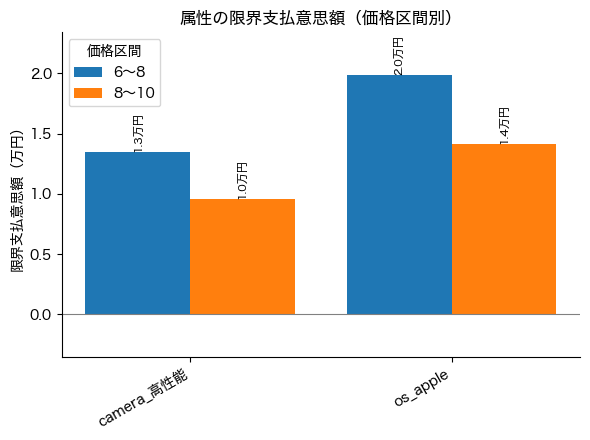

In [17]:
print("■ 区間別 WTP（デフォルト method='segment'）")
print(result3.wtp())

# 区間別 WTP をグループ化棒グラフで可視化（棒の高さは上の表と一致する）
ax = result3.plot_wtp(price_unit="万円")

**読み取り方**：同じ属性（例：Apple であること）の WTP が、`6〜8` 区間より `8〜10` 区間で
**小さく** なります。これは `8〜10` 区間の方が **価格に敏感**（1万円の値上げで効用が大きく
下がる）ため、同じ魅力でも金額換算が小さくなるからです。価格を2水準のままにしていたら
見えなかった、**価格帯による感応度の違い** が捉えられました。

# 補足

## A. この回答データについて（合成データ）

`responses_smartphone_google_30.csv` / `responses_smartphone_3price_40.csv` は
**実際の調査データではありません**。あらかじめ仮定した選好（Apple が好き・高性能カメラが
好き・高いと避ける、など）から確率的に生成した **合成データ** で、教材・動作確認用です。

生成スクリプトは `examples/make_demo_data.py` です。設計（`design_*.csv`）は
py4conjoint 純正のものを読み込んで使い、**設計とデータの対応がずれない** よう作ってあります。
`python make_demo_data.py` で再生成できます。

## B. 条件付きロジットの正しさ（外部検証）

本パッケージの条件付きロジット推定は、R の `logitr` パッケージに付属する
ヨーグルト購買データ（`tests/data/yogurt.csv`）で係数が一致することを
**自動テスト（`tests/`）で検証** しています。ノートブックでは推定の実演は行いません。

## C. rating 版（評点型）との違い

| 観点 | rating 版（評点型） | choice 版（選択型・CBC） |
|------|--------------------|--------------------------|
| 回答者のタスク | 製品案を1つずつ **採点**（例：10点満点） | 複数の製品案から **1つを選ぶ** |
| 統計モデル | OLS 回帰（評点を効用とみなす） | 条件付きロジット（選択確率をモデル化、最尤法） |
| 符号化 | **効果コーディング（−1/+1）**：係数は「全水準の平均との差」 | **ダミーコーディング（0/1）**：係数は「基準水準との差」 |
| 適合度 | R²（評点のばらつきの説明割合） | 擬似 R²（McFadden。別物なので直接比較不可） |
| `market_share()` の根拠 | 評点→効用→ロジット式は **追加の仮定** | ロジット式が **推定モデルそのもの**（理論的に一貫） |

ひとことで言うと：rating 版は「気持ち（評点）」を、choice 版は「行動（選択）」を
データにします。市場シェアの予測が目的なら、選択行動を直接モデル化している
choice 版の方が理論的な裏付けが強い、というのが使い分けの目安です。